In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as st
import statsmodels.formula.api as smf
import plotly.express as px

In [2]:
kc = pd.read_csv('kc_house_data.csv')

In [3]:
kc.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [4]:
# Change column type to datetime64[ns] for column: 'date'
# kc = kc.astype({'date': 'datetime64[s]'})
# kc.date.str[:8].astype('datetime64[s]')[0] # same result
kc['date'] = pd.to_datetime(kc.date)

In [5]:
sqft_to_sqmeters = 0.09290303997

In [6]:
kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float})

In [7]:
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

In [8]:
kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

In [9]:
kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

In [10]:
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan

In [11]:
kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan

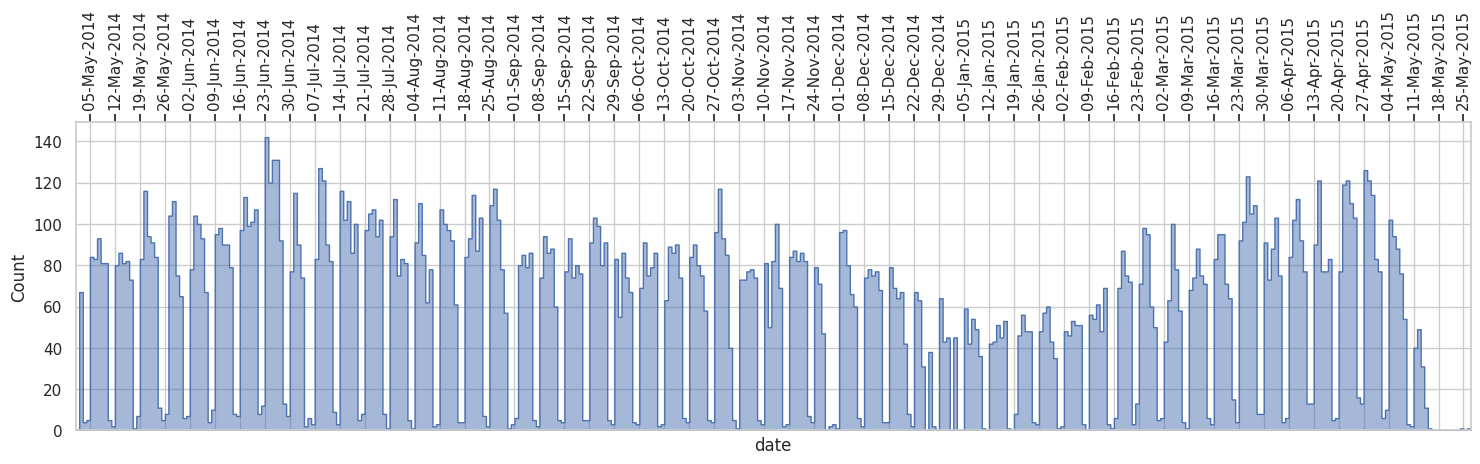

In [83]:
dates_limits = mpl.dates.date2num(np.datetime64(kc.date.min())) - 1,\
               mpl.dates.date2num(np.datetime64(kc.date.max()))
dates_range = mpl.dates.date2num(
    pd.date_range(start=kc.date.min(), end=kc.date.max(), freq='W-MON'))

fig, ax = plt.subplots(figsize=(18,4))
sns.set_style('whitegrid')
sns.histplot(kc.date, element='step', binwidth=1, alpha=0.5,
             binrange=(dates_limits)).set_xlim(dates_limits)

ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%d-%b-%Y'))
ax.xaxis.set_ticks_position('top')
plt.xticks(dates_range, rotation=90)
plt.show()

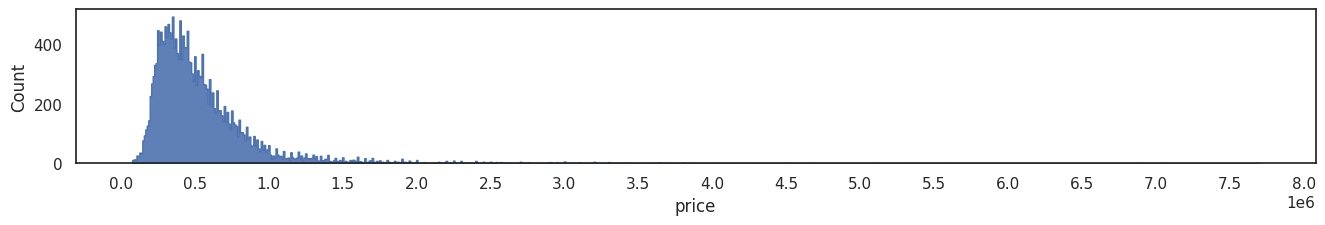

In [84]:
sns.set(rc={"figure.figsize":(16,2)})
sns.set_style('white')
sns.histplot(data=kc.price, element='step', binwidth=10**4, alpha=0.9)
plt.locator_params(nbins=27, axis='x')

In [13]:
pd.DataFrame(kc.floors.value_counts()).T

floors,1.0,2.0,1.5,3.0,2.5,3.5
count,10680,8241,1910,613,161,8


In [14]:
pd.DataFrame(kc.bedrooms.value_counts()).T

bedrooms,3,4,2,5,6,1,7,0,8,9,10,11,33
count,9824,6882,2760,1601,272,199,38,13,13,6,3,1,1


In [15]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,:15]

bathrooms,2.50,1.00,1.75,2.25,2.00,1.50,2.75,3.00,3.50,3.25,3.75,4.00,4.50,4.25,0.75
count,5380,3852,3048,2047,1930,1446,1185,753,731,589,155,136,100,79,72


In [16]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,15:]

bathrooms,4.75,5.00,5.25,0.00,5.50,1.25,6.00,0.50,5.75,6.75,8.00,6.50,6.25,7.75,7.50
count,23,21,13,10,10,9,6,4,4,2,2,2,2,1,1


In [17]:
kc[['waterfront', 'view', 'condition', 'grade']].apply(lambda x: x.value_counts()).T.fillna('')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
waterfront,21450.0,163.0,,,,,,,,,,,,
view,19489.0,332.0,963.0,510.0,319.0,,,,,,,,,
condition,,30.0,172.0,14031.0,5679.0,1701.0,,,,,,,,
grade,,1.0,,3.0,29.0,242.0,2038.0,8981.0,6068.0,2615.0,1134.0,399.0,90.0,13.0


Text(0.5, 0, 'square meters')

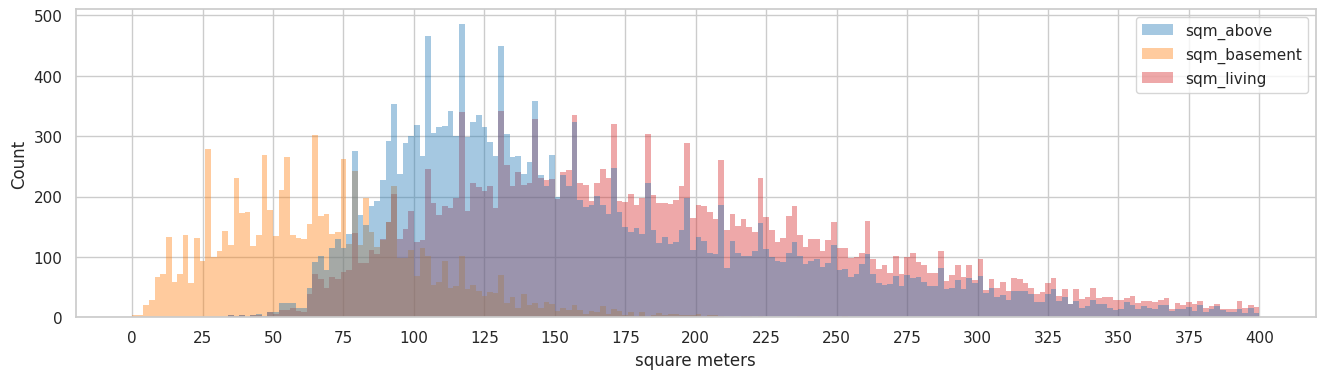

In [118]:
sns.set(rc={"figure.figsize":(16,4)})
sns.set_style('whitegrid')
sns.histplot(kc[['sqm_above', 'sqm_basement', 'sqm_living']],
             binrange=(0,400), binwidth=2, palette=['#1f77b4', '#ff7f0e', '#d62728'],
             kde=False, kde_kws={'clip':(0,400)},
             multiple='layer', element='step', alpha=0.4, linewidth=0)
plt.locator_params(axis='x', nbins=20)
plt.xlabel('square meters')

In [144]:
# px.histogram(kc, ['sqm_above', 'sqm_basement','sqm_living'],
#             color_discrete_sequence=px.colors.qualitative.T10,
#             template='simple_white', opacity=0.5,
#             range_y=[0,400], 
# ).update_traces(xbins_start=0, xbins_end=400, xbins_size=2,
#                 marker_line_width=0, marker_cornerradius=10
# ).update_layout(barmode='overlay',
#                 margin=dict(l=0,r=0,b=0,t=0), height = 300
# ).update_xaxes(title_standoff=0, ticks='inside',  showgrid=True, title_text='square meters'
# ).update_yaxes(title_standoff=0, ticks='inside',  showgrid=True)

Text(0.5, 0, 'log square meters')

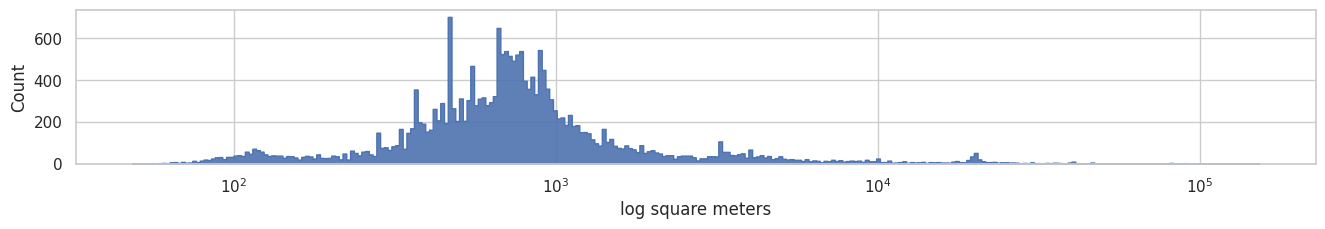

In [84]:
sns.set(rc={"figure.figsize":(16,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.sqm_lot, element='step', bins=300, alpha=0.9, log_scale=10)
plt.xlabel('log square meters')

In [21]:
kc.id.count()

np.int64(21613)

In [22]:
kc.loc[kc.sqm_living==kc.sqm_above,'sqm_above'].count()

np.int64(13126)

In [23]:
kc.loc[kc.sqm_above==kc.sqm_basement,'sqm_above'].count()

np.int64(551)

Text(0.5, 0, 'year built')

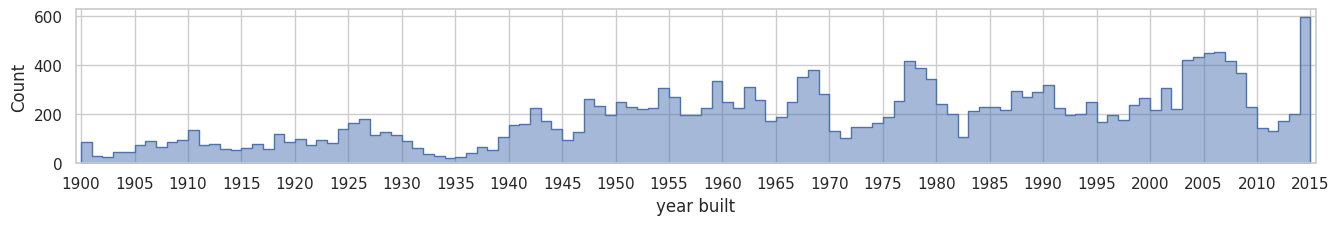

In [101]:
sns.set(rc={"figure.figsize":(16,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_built, binrange=(1900,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=40)
plt.xlim(1899.5,2015.5)
plt.xlabel('year built')

Text(0.5, 0, 'year of renovation')

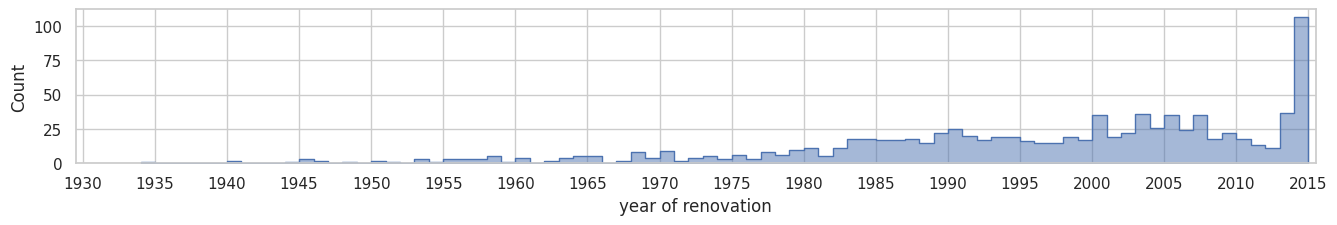

In [100]:
sns.set(rc={"figure.figsize":(16,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_renovated, binrange=(1934,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=30)
plt.xlim(1929.5,2015.5)
plt.xlabel('year of renovation')

In [142]:
px.scatter_map(kc, lat='lat', lon='long', size='sqm_living', size_max=10, zoom=9, template='plotly_dark',
               color='price', map_style='carto-darkmatter', color_continuous_scale='plasma'
               ).update_layout(margin=dict(l=0,r=0,b=0,t=0))